<a href="https://colab.research.google.com/github/tizwe/SPT-Simulation-Framework/blob/main/SPT_Simulation_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stochastic Portfolio Theory — Simulation Framework

# Part I — Framework

## Imports

In [ ]:
# Colab: only cvxpy is missing.
%pip install -q cvxpy
# Local installation of all dependencies:
# %pip install -q numpy pandas scipy matplotlib plotly ipywidgets tqdm joblib torch cvxpy nbformat

import numpy as np
import warnings
import pandas as pd
from joblib import Parallel, delayed
import multiprocessing
import torch
import cvxpy as cp
from collections.abc import Callable
from scipy.stats import ortho_group

# Visualization
import plotly.graph_objects as go
import plotly.offline as offline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from tqdm.auto import tqdm
from plotly.subplots import make_subplots
from IPython.display import display

## Market and Portfolio

In [ ]:
class Market:
    def __init__(
        self,
        n_stocks: int,
        n_bm: int,
        start_prices=None,
        drift=None,
        stock_volatilities=None,
        std_of_vola=0.0,
        market_factor_strength=0.0,
        seed=None,
    ):
        """
        Initializes a Market object.

        Args:
            n_stocks (int): Number of stocks.
            n_bm (int): Number of Brownian motions.
            start_prices (list, np.ndarray, optional): Initial stock prices (1D array of size n_stocks). Defaults to 1.0 for all stocks.
            drift (float, list, np.ndarray, optional): Rate of return b (arithmetic drift).
                                                       Can be a single float (applied to all stocks), a 1D array of size n_stocks,
                                                       or None (defaults to log(1.08)).
                                                       Note: This is NOT the geometric growth rate. The class internally applies
                                                       Itô correction by subtracting half the variance (0.5 * σ^2)
                                                       to calculate the true continuous growth rate for exponential simulations.
            stock_volatilities (float, list, np.ndarray, optional): Defines the volatility structure.
                                                                    - If a 2D array/list, it is used directly as the volatility matrix ξ.
                                                                    - If a float, it acts as the baseline target volatility (median).
                                                                      Individual stock volatilities are then drawn from a Log-Normal
                                                                      distribution around this target.
                                                                    - If None, defaults to a target volatility of 0.20 (20%).
            std_of_vola (float): Standard deviation of the Log-Normal distribution (Volatility of Volatility).
                                 Set to 0.0 to assign the exact baseline target volatility to all stocks.
            market_factor_strength (float): Injects a common market factor into the first Brownian motion.
                                            Higher absolute values increase positive covariance (correlation) among all stocks.
            seed (int, optional): Seed for the random number generator. If None, the generator is seeded non-deterministically.
        """

        self.n_stocks = n_stocks
        self.n_bm = n_bm
        self.x0 = self.__get_start_price(start_prices)
        self.drift_coefficients = self.__get_drift(drift)

        self.std_of_vola = std_of_vola
        self.market_factor_strength = market_factor_strength

        self.rng = np.random.default_rng(seed)
        self.volatility_matrix = self.__get_volatility_matrix(stock_volatilities)

        self.covariance_matrix = self.volatility_matrix @ self.volatility_matrix.T

    def __get_start_price(self, start_prices) -> np.ndarray:
        if start_prices is None:
            x0 = np.ones(self.n_stocks)
        elif isinstance(start_prices, (list, np.ndarray)):
            assert (
                len(start_prices) == self.n_stocks
            ), f"Initial prices length {len(start_prices)} does not match the number of stocks {self.n_stocks}"
            x0 = np.array(start_prices)
        else:
            raise ValueError(f"Unknown start_prices type: {type(start_prices)}")
        return x0

    def __get_drift(self, drift) -> np.ndarray:
        if drift is None:
            drift_coefficients = np.ones(self.n_stocks) * np.log(1.08)
        elif isinstance(drift, (float, int)):
            drift_coefficients = np.ones(self.n_stocks) * drift
        elif isinstance(drift, (list, np.ndarray)):
            assert (
                len(drift) == self.n_stocks
            ), f"Drift length {len(drift)} does not match the number of stocks {self.n_stocks}"
            drift_coefficients = np.array(drift)
        else:
            raise ValueError(f"Unknown drift type: {type(drift)}")
        return drift_coefficients

    def __get_volatility_matrix(self, stock_volatilities) -> np.ndarray:
        """
        Generates a random volatility matrix where each stock's volatility is
        distributed according to a Log-Normal distribution around a target level.
        If None, defaults to a target volatility of 0.20.
        Args:
            stock_volatilities (float, list, np.ndarray, optional): If float, treated as target volatility level (vola_target).
                                                                    If a 2D list/array of shape (n_stocks, n_bm),
                                                                    used directly as the volatility matrix.
        Returns:
            np.ndarray: Volatility matrix of shape (n_stocks, n_bm).
        """

        if stock_volatilities is None:
            vola_target = 0.20
        elif isinstance(stock_volatilities, (int, float)):
            vola_target = stock_volatilities
        elif isinstance(stock_volatilities, (list, np.ndarray)):
            volatility_matrix = np.asarray(stock_volatilities, dtype=float)
            assert volatility_matrix.shape == (self.n_stocks, self.n_bm), (
                f"Volatility matrix must be of shape ({self.n_stocks}, {self.n_bm}), "
                f"got {volatility_matrix.shape}."
            )
            return volatility_matrix
        else:
            raise ValueError("stock_volatilities must be None, a float, or an array.")

        # Sample individual target volatilities for each stock
        # We use mean = log(vola_target) so the Median is exactly vola_target.
        individual_target_volatilities = self.rng.lognormal(
            mean=np.log(vola_target), sigma=self.std_of_vola, size=self.n_stocks
        )

        seed_matrix = self.rng.normal(size=(self.n_stocks, self.n_bm))

        # Add a common market factor scaled by sqrt(n_bm) to make its impact invariant to the number of dimensions.
        seed_matrix[:, 0] = seed_matrix[:, 0] + (self.market_factor_strength * np.sqrt(self.n_bm))

        # Normalize rows to match individual target volatilities
        current_row_norms = np.linalg.norm(seed_matrix, axis=1)

        # Calculate scaling factors to enforce: ||ξ_i|| = individual_target_volatility[i]
        # This ensures the variance σ_ii = ||ξ_i||² matches the squared target volatility.
        scaling_factors = individual_target_volatilities / current_row_norms

        volatility_matrix = seed_matrix * scaling_factors[:, np.newaxis]

        return volatility_matrix

    def set_custom_volatility_matrix(self, custom_matrix: np.ndarray):
        """
        Sets a custom volatility matrix and updates the covariance matrix accordingly.
        The number of Brownian motions n_bm is adjusted to the number of columns of the
        provided matrix.

        Args:
            custom_matrix (np.ndarray): Volatility matrix of shape (n_stocks, d).
        """
        volatility_matrix = np.asarray(custom_matrix, dtype=float)

        assert volatility_matrix.ndim == 2, (
            f"Volatility matrix must be two-dimensional, "
            f"got {volatility_matrix.ndim} dimension(s)."
        )
        assert volatility_matrix.shape[0] == self.n_stocks, (
            f"Volatility matrix must have exactly {self.n_stocks} rows to match n_stocks, "
            f"got {volatility_matrix.shape[0]}."
        )

        self.volatility_matrix = volatility_matrix
        self.covariance_matrix = volatility_matrix @ volatility_matrix.T

        new_n_bm = volatility_matrix.shape[1]
        if self.n_bm != new_n_bm:
            warnings.warn(
                f"Number of Brownian motions (n_bm) changed from {self.n_bm} to {new_n_bm} "
                f"to match the dimensions of the provided volatility matrix."
            )
        self.n_bm = new_n_bm

    def set_custom_covariance_matrix(self, custom_cov: np.ndarray):
        """
        Sets a custom covariance matrix and derives the corresponding volatility matrix
        via spectral decomposition. The number of Brownian motions n_bm is adjusted to
        the rank of the provided matrix.

        Args:
            custom_cov (np.ndarray): Symmetric positive semi-definite matrix of shape
                (n_stocks, n_stocks).
        """
        covariance_matrix = np.asarray(custom_cov, dtype=float)

        assert covariance_matrix.shape == (self.n_stocks, self.n_stocks), (
            f"Covariance matrix must be of shape ({self.n_stocks}, {self.n_stocks}), "
            f"got {covariance_matrix.shape}."
        )
        if not np.allclose(covariance_matrix, covariance_matrix.T, atol=1e-8):
            raise ValueError("The provided covariance matrix is not symmetric.")

        # A = Q * Lambda * Q^T
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

        psd_tolerance = -1e-8
        if np.min(eigenvalues) < psd_tolerance:
            raise ValueError(
                f"Invalid covariance matrix. It is not positive semi-definite. "
                f"Smallest eigenvalue is {np.min(eigenvalues):.4e}"
            )
        eigenvalues = np.clip(eigenvalues, 0.0, None)

        # Effective rank via a relative tolerance threshold
        max_eig = np.max(eigenvalues) if eigenvalues.size > 0 else 0.0
        tol = 1e-10 * max_eig if max_eig > 0 else 1e-12
        non_zero_factors = eigenvalues > tol

        # B = Q * Lambda^(1/2), reduced to the non-zero factors
        volatility_matrix = eigenvectors[:, non_zero_factors] * np.sqrt(
            eigenvalues[non_zero_factors]
        )

        self.covariance_matrix = covariance_matrix
        self.volatility_matrix = volatility_matrix

        new_n_bm = volatility_matrix.shape[1]
        if self.n_bm != new_n_bm:
            warnings.warn(
                f"Number of Brownian motions (n_bm) changed from {self.n_bm} to {new_n_bm} "
                f"to match the rank of the derived volatility matrix."
            )
        self.n_bm = new_n_bm

    def simulate_prices_exp(self, dt, T) -> np.ndarray:
        """
        Simulates stock prices via the exact solution of the log-normal SDE.

        Args:
            dt (float): Time step size.
            T (float): Time horizon.

        Returns:
            np.ndarray: Price paths of shape (n_stocks, int(T/dt) + 1).
        """
        num_steps = int(T / dt)
        stock_prices = np.zeros((self.n_stocks, num_steps + 1))
        stock_prices[:, 0] = self.x0
        growth_rate = self.drift_coefficients - 0.5 * np.diag(self.covariance_matrix)
        for t in range(0, num_steps):
            dW = np.sqrt(dt) * self.rng.standard_normal(self.n_bm)
            diffusion = self.volatility_matrix @ dW
            stock_prices[:, t + 1] = stock_prices[:, t] * np.exp(growth_rate * dt + diffusion)

        return stock_prices

    def simulate_prices_rank(self, dt, T) -> np.ndarray:
        """
        Simulates stock prices in a rank-based model.

        At each time step the drift coefficients are assigned by rank: the k-th entry of
        drift_coefficients is applied to the stock currently holding rank k, where rank 0
        denotes the largest capitalization. Volatilities remain stock-specific and are not
        reassigned by rank.

        Args:
            dt (float): Time step size.
            T (float): Time horizon.

        Returns:
            np.ndarray: Price paths of shape (n_stocks, int(T/dt) + 1).
        """

        num_steps = int(T / dt)
        stock_prices = np.zeros((self.n_stocks, num_steps + 1))
        stock_prices[:, 0] = self.x0
        ito_correction = 0.5 * np.diag(self.covariance_matrix)
        for t in range(0, num_steps):
            ranked_indices = np.argsort(stock_prices[:, t])[::-1]
            drift = np.zeros(self.n_stocks)
            # drift_coefficients[k] is the drift of the stock ranked k-th, not of stock k
            drift[ranked_indices] = self.drift_coefficients
            growth_rate = drift - ito_correction
            dW = np.sqrt(dt) * self.rng.standard_normal(self.n_bm)
            diffusion = self.volatility_matrix @ dW
            stock_prices[:, t + 1] = stock_prices[:, t] * np.exp(growth_rate * dt + diffusion)

        return stock_prices

In [ ]:
class Portfolio:
    def __init__(
        self,
        m,
        update_rule,
        x0=1.0,
        initial_weights=None,
        update_frequency=1,
        name=None,
    ):
        """
        Initializes a Portfolio object.

        Args:
            m (Market): Market environment.
            update_rule (str or callable): Update rule for the portfolio weights.
              - If str, must be one of:
                      * 'market_weights': Weights match market capitalization.
                      * 'equal_weights': Rebalances to 1/n at every step.
                      * 'random_weights': Assigns random weights at every step.
                      * 'constant_weights': Rebalances to the initial weights at every step.
                      * 'buy_and_hold': Weights drift with stock returns (no active trading).
              - If callable: A function `f(market_weights) -> np.ndarray` that computes new weights.
            x0 (float): Initial porfolio value. Defaults to 1.
            initial_weights (np.ndarray, list, str, optional): Starting weights at t=0.
              - If np.ndarray/list: Explicit weights (must sum to ~1).
              - If str: 'market' (market cap), 'equal' (1/n), or 'random'.
              - If None (default): Automatically determined based on `update_rule`.
                  * For 'market/equal/random_weights' rules, this matches the rule.
                  * For 'constant/buy_and_hold', defaults to 'market'.
                  * For callables, calculated using the function on initial data.
            update_frequency (int): Apply update rule every update_frequency'th time step.
            name (str): Name of the portfolio. If None, the update rule is used.
        """

        self.m = m
        self.x0 = x0
        self.update_rule = update_rule
        self.weights = self.__get_initial_weights(initial_weights)
        self.initial_weights = self.weights.copy()
        self.update_frequency = update_frequency
        self.name = self.__get_name(name)

        # Track Growth
        self.log_relative_wealth = [0.0]

    def __get_initial_weights(self, initial_weights) -> np.ndarray:
        """
        Constructs the initial weights for the portfolio based on the selected type.

        Args:
            initial_weights: Either Array of Initial weights or name of the type of initial weights.
        Returns:
            np.ndarray: Constructed initial weights.
        """
        initial_w_type = self.__get_initial_weights_type(initial_weights)
        initial_market_weights = self.m.x0 / np.sum(self.m.x0)
        if initial_w_type == "calculate":
            initial_weights = self.update_rule(initial_market_weights)

        match initial_w_type:
            case "random":
                new_weights = self.m.rng.dirichlet(np.ones(self.m.n_stocks) * 10, size=1)[0]
            case "equal":
                new_weights = np.ones(self.m.n_stocks) / self.m.n_stocks
            case "market":
                new_weights = initial_market_weights
            case "custom" | "calculate":
                assert isinstance(
                    initial_weights, (list, np.ndarray)
                ), f"Initial weights must be a list or a numpy array. Is {type(initial_weights)} instead"
                assert (
                    len(initial_weights) == self.m.n_stocks
                ), f"Initial weights length {len(initial_weights)} does not match the number of stocks {self.m.n_stocks}"
                assert (
                    abs(1 - np.sum(initial_weights)) < 1e-3
                ), f"Initial weights must sum to 1 - sum up to {np.sum(initial_weights)} instead."
                new_weights = initial_weights
            case _:
                raise ValueError(
                    f"Unknown initial weights type: {initial_weights}. Use manual weights or 'random', 'equal' or 'market' instead."
                )
        new_weights = self.__validate_weights(new_weights)
        return new_weights

    def __get_initial_weights_type(self, initial_weights) -> str:
        """
        Determines the type of initial weights based on the update rule and provided initial weights.
        Args:
            initial_weights (np.ndarray or str): Initial weights or their type.
        Returns:
            str: Type of initial weights. Either "random", "equal", "market", "custom", or "calculate".
        """

        if isinstance(initial_weights, str):
            initial_weights = initial_weights.lower()

        if self.update_rule in ("market_weights", "equal_weights", "random_weights"):
            if initial_weights is not None:
                warnings.warn(
                    f"Ignoring provided weights, since update rule is set to {self.update_rule}"
                )
            initial_weights_type = self.update_rule.split("_")[0]  # "market", "equal", or "random"
        elif self.update_rule in ("constant_weights", "buy_and_hold"):
            if initial_weights is None:
                warnings.warn(
                    f"Using {self.update_rule} but no initial weights given. Using market weights as initial weights instead."
                )
                initial_weights_type = "market"
            else:
                if isinstance(initial_weights, str):
                    initial_weights_type = initial_weights
                else:
                    initial_weights_type = "custom"
        elif callable(self.update_rule):
            if initial_weights is None:
                initial_weights_type = "calculate"
            elif isinstance(initial_weights, str):
                initial_weights_type = initial_weights
            else:
                initial_weights_type = "custom"
        else:
            raise ValueError(f"Unknown update rule: {self.update_rule}")

        return initial_weights_type

    def __get_name(self, name):
        if name is not None:
            return name
        if isinstance(self.update_rule, str):
            return self.update_rule
        if callable(self.update_rule):
            return self.update_rule.__name__
        return "Unknown_Portfolio"

    def get_tau(self) -> np.ndarray:
        """
        Calculates the relative covariance matrix.

        Returns:
            np.ndarray: Tau matrix.
        """
        cov = self.m.covariance_matrix
        cov_i_w = cov @ self.weights
        cov_w_w = self.weights @ cov @ self.weights.T
        tau = cov - cov_i_w[:, None] - cov_i_w[None, :] + cov_w_w
        return tau

    def get_growth_rate(self) -> float:
        """
        Calculates the growth rate of the portfolio.

        Returns:
            float: Growth rate.
        """
        excess_growth_rate = self.get_excess_growth_rate()
        average_growth = (
            self.m.drift_coefficients - 0.5 * np.diag(self.m.covariance_matrix)
        ) @ self.weights
        return excess_growth_rate + average_growth

    def get_excess_growth_rate(self) -> float:
        """
        Calculates the excess growth rate of the portfolio.

        Returns:
            float: Excess growth rate.
        """
        cov = self.m.covariance_matrix
        # Calculate the first term: Σ_{i=1}^n w_i σ_ii
        sum_w_cov_ii = np.sum(self.weights * np.diag(cov))
        # Calculate the second term: Σ_{i,j =1}^n w_i w_j σ_ij
        sum_w_w_cov_ij = self.weights @ cov @ self.weights
        # Calculate excess growth rate
        excess_growth_rate = 0.5 * (sum_w_cov_ii - sum_w_w_cov_ij)
        return excess_growth_rate

    def get_excess_growth_rate_from_tau(self, tau=None) -> float:
        """
        Alternative way for calculating the excess growth rate, using the relative covariance.
        Args:
            tau (np.ndarray, optional): Relative covariance matrix of shape
                (n_stocks, n_stocks). Computed from the current weights if not given.
        Returns:
            float: Excess growth rate.
        """

        if tau is None:
            tau = self.get_tau()
        sum_w_tau_ii = np.sum(self.weights * np.diag(tau))
        excess_growth_rate = 0.5 * sum_w_tau_ii
        return excess_growth_rate

    def __validate_weights(self, weights):
        weights = np.asarray(weights, dtype=float)
        total = np.sum(weights)
        if abs(total - 1) > 1e-3:
            # Only raise a warning on significant deviations from 1
            warnings.warn(
                f"Portfolio weights do not sum to 1 - sum up to {total} instead. Weights have been normalized."
            )
            weights = weights / total

        return weights

    def update_weights(self, market_weights, r=None, apply_update_rule=True):
        """
        Updates the portfolio weights based on the given market weights.

        Args:
            market_weights (np.ndarray): Market weights.
            r (np.ndarray): Stock returns over the current step. Needed when the weights are not rebalanced.
            apply_update_rule (bool): If True, the update rule is applied. If False, weights are only adjusted according to the stock movements
        """
        if r is None:
            r = np.ones(self.m.n_stocks)

        if not apply_update_rule:
            new_weights = self.weights * r / np.sum(self.weights * r)
        elif self.update_rule in ("constant_weights", "equal_weights"):
            new_weights = self.initial_weights.copy()
        elif self.update_rule == "random_weights":
            new_weights = self.m.rng.dirichlet(np.ones(len(self.weights)) * 10, size=1)[0]
        elif self.update_rule == "buy_and_hold":
            new_weights = self.weights * r / np.sum(self.weights * r)
        elif self.update_rule == "market_weights":
            new_weights = market_weights
        elif callable(self.update_rule):
            new_weights = self.update_rule(market_weights)
        else:
            raise ValueError(f"Unknown update rule type: {type(self.update_rule)}")
        self.weights = self.__validate_weights(new_weights)

    def simulate_value_process(self, stock_prices: np.ndarray) -> list:
        """
        Simulates the value process of the portfolio given stock prices.
        Args:
            stock_prices (np.ndarray): Stock prices (2D array of size n_stocks x time_steps).
        Returns:
            list: Simulated value process.
        """

        value_process = [self.x0]
        self.weights = self.initial_weights.copy()
        self.log_relative_wealth = [0.0]
        for t in range(1, len(stock_prices[0])):
            # Calculate stock returns
            stock_returns = stock_prices[:, t] / stock_prices[:, t - 1]

            # Calculate portfolio returns
            portfolio_return = np.sum(self.weights * stock_returns)
            value_process.append(value_process[-1] * portfolio_return)

            # Rebalance
            apply_update = (
                t % self.update_frequency == 0
            )  # Only apply Update rule, when it matches the update frequency
            current_market_weights = stock_prices[:, t] / np.sum(stock_prices[:, t])
            self.update_weights(current_market_weights, stock_returns, apply_update)

            # Track relative Log-wealth process
            market_value_t = (np.sum(stock_prices[:, t]) / np.sum(stock_prices[:, 0])) * self.x0
            self.log_relative_wealth.append(np.log(value_process[-1] / market_value_t))

        return value_process

In [ ]:
def simulate_paths(m: Market, T, dt, portfolios=None, by_rank=False):
    """
    Simulates stock price paths and evaluates the given portfolios along them.

    Args:
        m (Market): Market environment.
        T (float): Time horizon.
        dt (float): Time step size.
        portfolios (list, optional): Portfolio objects to evaluate. Defaults to None.
        by_rank (bool): If True, uses the rank-based model instead of the exponential one.

    Returns:
        tuple:
            - np.ndarray: Stock price paths of shape (n_stocks, int(T/dt) + 1).
            - list: One value process (list of floats) per portfolio, in the given order.
    """
    if portfolios is None:
        portfolios = []

    stock_prices = m.simulate_prices_rank(dt, T) if by_rank else m.simulate_prices_exp(dt, T)
    value_processes = [p.simulate_value_process(stock_prices) for p in portfolios]

    return stock_prices, value_processes

### Helper Functions

In [ ]:
def mu_max(prices: np.ndarray) -> np.ndarray:
    """
    Calculates the largest market weight at each time step.

    Args:
        prices (np.ndarray): Stock prices of shape (n_stocks, time_steps).

    Returns:
        np.ndarray: Largest market weight per time step, of shape (time_steps,).
    """
    return np.max(prices, axis=0) / np.sum(prices, axis=0)


def market_factor_variance_share(strength: float, n_bm: int) -> float:
    """
    Share of total variance explained by the common market factor, in percent.

    Args:
        strength (float): Market factor strength passed to the Market class.
        n_bm (int): Number of Brownian motions.

    Returns:
        float: Percentage of total variance attributable to the market factor.
    """
    return ((1 + strength**2 * n_bm) / (n_bm * (strength**2 + 1))) * 100


def median_absolute_deviation(data: np.ndarray) -> float:
    """
    Calculates the Median Absolute Deviation (MAD) of the given data.

    Args:
        data (np.ndarray): Input data (1D array).

    Returns:
        float: Median Absolute Deviation.
    """
    median = np.median(data)
    deviations = np.abs(data - median)
    mad = float(np.median(deviations))
    return mad


def relative_mad(data: np.ndarray) -> float:
    """
    Calculates the relative median absolute deviation (RMAD) of the given data.

    RMAD(X) = Median(|X_i - median(X)|) / |median(X)|, the median-based counterpart of
    the coefficient of variation σ/μ.

    Args:
        data (np.ndarray): Input data (1D array). Its median must be non-zero.

    Returns:
        float: Median absolute deviation divided by the absolute median.
    """
    median = np.median(data)
    if median == 0:
        raise ValueError("Median is zero, cannot compute relative MAD.")

    return float(median_absolute_deviation(data) / abs(median))

## Functionally Generated Portfolios

In [ ]:
def fgp_from_generating_function(g: Callable) -> Callable[[np.ndarray], np.ndarray]:
    """
    Constructs a functionally generated portfolio generator.

    Maps market weights μ(t) to portfolio weights π(t) using the master equation:
        π_i(t) = ( D_i log G(μ(t)) + 1 - Σ_j [ μ_j(t) D_j log G(μ(t)) ] ) μ_i(t)

    The gradient ∇ log G(μ) is computed via automatic differentiation in a single
    backward pass.

    Caution: This generic implementation is slow; for long runs, differentiate G by
    hand and implement π directly.

    Args:
        g (Callable): Generating function G(μ) accepting a PyTorch tensor on the
            simplex and returning a positive scalar.

    Returns:
        Callable: Portfolio update function π(μ, *args) returning the generated
            weights as a NumPy array.
    """

    def generator(m_weights: np.ndarray, *args) -> np.ndarray:
        # Convert market weights to a tensor with gradient tracking
        x_tensor = torch.tensor(m_weights, dtype=torch.float64, requires_grad=True)

        g_value = g(x_tensor)
        if g_value.dim() > 0:
            raise ValueError("Generating function G must return a scalar value.")
        if g_value <= 0:
            raise ValueError(f"Generating function G must be positive, got {g_value.item()}.")

        y = torch.log(g_value)

        # Compute all partial derivatives D_i log G(μ) at once: ∇ log G(μ)
        grad = torch.autograd.grad(y, x_tensor)[0]

        mu = x_tensor.detach()

        # Inner product term: Σ_j [ μ_j D_j log G(μ) ]
        sum_term = torch.dot(grad, mu)

        new_weights = (grad + 1.0 - sum_term) * mu

        return new_weights.numpy()

    generator.__name__ = getattr(g, "__name__", "generated")

    return generator

### Generating Functions

In [ ]:
# Standard functional generating functions


def gen_diversity_generator(p: float) -> Callable:
    """
    Returns a generating function for a Diversity Portfolio.
    G_p(μ) = (Σ μ_i^p)^(1/p)
    """

    def gen_diversity(x: torch.Tensor) -> torch.Tensor:
        return torch.pow(torch.sum(torch.pow(x, p)), 1 / p)

    return gen_diversity


def gen_equal_weight(x: torch.Tensor) -> torch.Tensor:
    """
    Generating function for the Equally Weighted Portfolio.
    G(μ) = (μ_1 * μ_2 * ... * μ_n)^(1/n)
    """
    n = len(x)
    return torch.prod(torch.pow(x, 1 / n))


def gen_entropy(x: torch.Tensor) -> torch.Tensor:
    """
    Generating function based on Shannon Entropy.
    H(μ) = - Σ (μ_i * log(μ_i))
    """
    eps = 1e-12
    x_safe = torch.clamp(x, min=eps)
    return -torch.sum(x_safe * torch.log(x_safe))


def gen_quadratic(x: torch.Tensor) -> torch.Tensor:
    """
    Quadratic generating function used in the relative arbitrage construction.
    G(μ) = 1 - 0.5 * Σ μ_i²

    Under non-degeneracy and weak diversity this generates a portfolio that
    outperforms the market on [0, T] (cf. Section "Constructing a Relative
    Arbitrage Portfolio").
    """
    return 1 - 0.5 * torch.sum(torch.pow(x, 2))


# Those can be used directly as 'update_rule' in the Portfolio class
quadratic = fgp_from_generating_function(gen_quadratic)
diversity_p05 = fgp_from_generating_function(gen_diversity_generator(p=0.5))
shannon_entropy = fgp_from_generating_function(gen_entropy)
equal_weighted = fgp_from_generating_function(gen_equal_weight)

# Example of a portfolio rule defined directly on the market weights (not functionally generated)


def inverse_market_weights(m_weights: np.ndarray) -> np.ndarray:
    """
    Calculates weights proportional to the reciprocal of the market weights.
    """
    inv_w = 1.0 / m_weights
    return inv_w / np.sum(inv_w)

# Part II — Numerical Experiments

## A Simulated Stock Market

In [ ]:
# Market plot parameters
T_MARKET = 25
DT_MARKET = 0.1
N_S_MARKET = 10
N_BM_MARKET = 15


def interactive_market_plot(
    vola=0.1,
    std_of_vola=0.0,
    drift=1.08,
    market_factor=0.0,
    seed_number=42,
    y_scale="log",
):
    """
    Simulates and visualizes multi-asset price paths.

    The seed is passed to the Market object, so changing volatility or the market
    factor while keeping the seed fixed shows the isolated effect of that parameter
    on the same underlying Brownian motions.

    Args:
        vola (float): Target volatility (median across stocks).
        std_of_vola (float): Spread of the individual volatilities around the target.
            At 0.0 all stocks share the same volatility.
        drift (float): Rate of return per year, e.g. 1.08 for 8%.
        market_factor (float): Strength of the common market factor.
        seed_number (int): Seed for the market's random number generator.
        y_scale (str): "log" or "linear" scale for the price axis.
    """
    market = Market(
        n_stocks=N_S_MARKET,
        n_bm=N_BM_MARKET,
        drift=np.log(drift),
        stock_volatilities=vola,
        std_of_vola=std_of_vola,
        market_factor_strength=market_factor,
        seed=seed_number,
    )

    stock_prices = market.simulate_prices_exp(DT_MARKET, T_MARKET)
    time_steps = np.linspace(0, T_MARKET, int(T_MARKET / DT_MARKET) + 1)

    plt.figure(figsize=(12, 5), dpi=200)
    for i in range(len(stock_prices)):
        plt.plot(time_steps, stock_prices[i, :], linewidth=1.0)

    plt.xlabel("Time [Years]")
    plt.ylabel(f"Price ({y_scale.capitalize()})")
    plt.title(
        f"Simulation of a market with {N_S_MARKET} stocks "
        f"(volatility {vola:.2f}, market factor {market_factor:.1f})"
    )
    plt.yscale(y_scale)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


style = {"description_width": "140px"}
slider_layout = widgets.Layout(width="330px")

m_vola = widgets.FloatSlider(
    min=0.0,
    max=0.6,
    step=0.025,
    value=0.1,
    description="Volatility",
    style=style,
    layout=slider_layout,
)
m_std_vola = widgets.FloatSlider(
    min=0.0,
    max=1.0,
    step=0.025,
    value=0.0,
    description="Volatility Spread",
    style=style,
    layout=slider_layout,
)
m_drift = widgets.FloatSlider(
    min=0.9,
    max=1.5,
    step=0.02,
    value=1.08,
    description="Rate of Return",
    style=style,
    layout=slider_layout,
)
m_mf = widgets.FloatSlider(
    min=0.0,
    max=3.0,
    step=0.1,
    value=0.0,
    description="Market Factor",
    style=style,
    layout=widgets.Layout(width="260px"),
)
m_seed = widgets.IntSlider(
    min=0,
    max=100,
    value=42,
    description="Simulation Seed",
    style=style,
    layout=slider_layout,
)
m_scale = widgets.Dropdown(
    options=[("Logarithmic", "log"), ("Linear", "linear")],
    value="log",
    description="Y-Axis Scale",
    style=style,
    layout=slider_layout,
)


def market_variance_share_html(strength: float) -> str:
    pct = market_factor_variance_share(strength, N_BM_MARKET)
    return (
        "<div style='color: #666; font-size: 0.95em; margin-left: 4px;"
        " display: inline-block; min-width: 175px; font-variant-numeric:"
        f" tabular-nums;'><i>({pct:4.1f}% of total variance)</i></div>"
    )


m_mf_pct = widgets.HTML(value=market_variance_share_html(m_mf.value))
m_mf.observe(
    lambda change: setattr(m_mf_pct, "value", market_variance_share_html(change.new)),
    names="value",
)

m_mf_row = widgets.HBox([m_mf, m_mf_pct], layout=widgets.Layout(align_items="center"))

market_ui = widgets.HBox(
    [
        widgets.VBox([m_vola, m_std_vola]),
        widgets.VBox([m_mf_row, m_drift]),
        widgets.VBox([m_seed, m_scale]),
    ],
    layout=widgets.Layout(width="100%", justify_content="space-around"),
)

market_out = widgets.interactive_output(
    interactive_market_plot,
    {
        "vola": m_vola,
        "std_of_vola": m_std_vola,
        "drift": m_drift,
        "market_factor": m_mf,
        "seed_number": m_seed,
        "y_scale": m_scale,
    },
)

display(market_ui, market_out)

Output()

## The Optimization Landscape of the Growth-Optimal Portfolio

In [ ]:
IDENTICAL_TOL = 1e-2  # distance below which the two optima are treated as identical


def _add_optima_markers(fig, res_long_only, res_long_short):
    """
    Adds the optimum markers to a growth-rate surface plot.

    Args:
        fig (go.Figure): Figure to add the markers to.
        res_long_only (dict): Result of the long-only optimization, with keys "x" and "fun".
        res_long_short (dict or None): Result of the long-short optimization, or None.
    """

    def hover(label, x, f):
        coords = "<br>".join(f"π{i + 1}={v:.3f}" for i, v in enumerate(x))
        return f"{label}<br>{coords}<br>γ_π={-f:.5f}<extra></extra>"

    x_lo, f_lo = res_long_only["x"], res_long_only["fun"]
    x_ls = res_long_short["x"] if res_long_short else None
    f_ls = res_long_short["fun"] if res_long_short else None

    if x_ls is not None and np.linalg.norm(x_lo - x_ls) < IDENTICAL_TOL:
        fig.add_trace(
            go.Scatter3d(
                x=[x_lo[0]],
                y=[x_lo[1]],
                z=[-f_lo],
                mode="markers",
                marker=dict(size=10, color="purple", symbol="diamond"),
                name="Long-only = Long-short",
                hovertemplate=hover("Identical optimum", x_lo, f_lo),
            )
        )
        return

    fig.add_trace(
        go.Scatter3d(
            x=[x_lo[0]],
            y=[x_lo[1]],
            z=[-f_lo],
            mode="markers",
            marker=dict(size=9, color="red", symbol="circle"),
            name="Long-only optimum",
            hovertemplate=hover("Long-only", x_lo, f_lo),
        )
    )
    if x_ls is not None:
        fig.add_trace(
            go.Scatter3d(
                x=[x_ls[0]],
                y=[x_ls[1]],
                z=[-f_ls],
                mode="markers",
                marker=dict(size=9, color="blue", symbol="diamond"),
                name="Long-short optimum",
                hovertemplate=hover("Long-short", x_ls, f_ls),
            )
        )


def _plot_surface_2d(res_long_only, res_long_short, loss):
    """
    Visualizes the optimization landscape for 2 assets.

    Args:
        res_long_only (dict): Result of the long-only optimization, with keys "x" and "fun".
        res_long_short (dict or None): Result of the long-short optimization, or None if
            it was not computed.
        loss (callable): Objective function of the quadratic program, evaluated on the
            grid. Returns the negative growth rate.
    """
    x1_range = np.linspace(-0.5, 1.5, 100)
    x2_range = np.linspace(-0.5, 1.5, 100)
    X1, X2 = np.meshgrid(x1_range, x2_range)

    F = np.empty_like(X1)
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            F[i, j] = loss(np.array([X1[i, j], X2[i, j]]))
    Z = -F

    hover_text = np.empty(X1.shape, dtype=object)
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            hover_text[i, j] = f"π₁={X1[i, j]:.3f}<br>π₂={X2[i, j]:.3f}<br>γ_π={Z[i, j]:.5f}"

    fig = go.Figure(
        data=go.Surface(
            x=X1,
            y=X2,
            z=Z,
            colorscale="Viridis",
            opacity=0.85,
            hoverinfo="text",
            text=hover_text,
            name="Growth Surface",
            colorbar=dict(title="Growth γ", x=-0.15, len=0.7, thickness=15),
        )
    )

    # Budget constraint: the line where the weights sum to one
    p1_line = np.linspace(-0.2, 1.2, 100)
    p2_line = 1 - p1_line
    z_line = np.array([-loss(np.array([p, 1 - p])) for p in p1_line])

    fig.add_trace(
        go.Scatter3d(
            x=p1_line,
            y=p2_line,
            z=z_line,
            mode="lines",
            line=dict(color="red", width=6),
            name="Budget constraint (Σπ = 1)",
        )
    )

    _add_optima_markers(fig, res_long_only, res_long_short)

    fig.update_layout(
        title="Portfolio Growth Rate (2 assets)",
        width=900,
        height=600,
        margin=dict(l=20, r=50, t=40, b=0),
        scene=dict(xaxis_title="π₁", yaxis_title="π₂", zaxis_title="Growth γ"),
        legend=dict(x=0.8, y=0.9),
    )
    offline.iplot(fig)


def _plot_surface_full(res_long_only, res_long_short, loss):
    """
    Visualizes the optimization landscape for 3 assets on the budget hyperplane Σπ = 1.

    The surface is drawn over π₁, π₂ ∈ [-0.5, 1.5] with π₃ = 1 - π₁ - π₂, so it covers the
    full hyperplane rather than only the simplex. The simplex boundary is marked in red.

    Args:
        res_long_only (dict): Result of the long-only optimization, with keys "x" and "fun".
        res_long_short (dict or None): Result of the long-short optimization, or None if
            it was not computed.
        loss (callable): Objective function of the quadratic program, evaluated on the
            grid. Returns the negative growth rate.
    """
    x1_range = np.linspace(-0.5, 1.5, 100)
    x2_range = np.linspace(-0.5, 1.5, 100)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    X3 = 1 - X1 - X2

    F = np.empty_like(X1)
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            F[i, j] = loss(np.array([X1[i, j], X2[i, j], X3[i, j]]))
    Z = -F

    hover_text = np.empty(X1.shape, dtype=object)
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            hover_text[i, j] = (
                f"π₁={X1[i, j]:.3f}<br>π₂={X2[i, j]:.3f}<br>"
                f"π₃={X3[i, j]:.3f}<br>γ_π={Z[i, j]:.5f}"
            )

    fig = go.Figure(
        data=go.Surface(
            x=X1,
            y=X2,
            z=Z,
            colorscale="Viridis",
            opacity=0.8,
            hoverinfo="text",
            text=hover_text,
            name="Growth Surface",
            colorbar=dict(title="Growth γ", x=-0.15, len=0.7, thickness=15),
        )
    )

    edges = [
        (np.linspace(0, 1, 100), np.zeros(100)),
        (np.zeros(100), np.linspace(0, 1, 100)),
        (np.linspace(0, 1, 100), 1 - np.linspace(0, 1, 100)),
    ]

    for p1_edge, p2_edge in edges:
        p3_edge = 1 - p1_edge - p2_edge
        z_edge = -np.array(
            [loss(np.array([p1, p2, p3])) for p1, p2, p3 in zip(p1_edge, p2_edge, p3_edge)]
        )
        fig.add_trace(
            go.Scatter3d(
                x=p1_edge,
                y=p2_edge,
                z=z_edge,
                mode="lines",
                line=dict(color="red", width=6),
                showlegend=False,
            )
        )

    # Invisible trace to get a single legend entry for all three edges
    fig.add_trace(
        go.Scatter3d(
            x=[None],
            y=[None],
            z=[None],
            mode="lines",
            line=dict(color="red", width=6),
            name="Simplex boundary",
        )
    )

    _add_optima_markers(fig, res_long_only, res_long_short)

    fig.update_layout(
        title="Portfolio Growth Rate (3 assets)",
        width=900,
        height=600,
        margin=dict(l=20, r=50, t=40, b=0),
        scene=dict(xaxis_title="π₁", yaxis_title="π₂", zaxis_title="Growth γ"),
        legend=dict(x=0.8, y=0.9),
    )
    offline.iplot(fig)

In [ ]:
def solve_portfolio(market, visualize_results=False, print_results=False) -> dict:
    """
    Solves for the growth-optimal portfolio.

    The asymptotic growth rate of a portfolio π in this market model is

        γ_π = π'b - 0.5 * π'σπ,

    where b is the vector of arithmetic drift rates (market.drift_coefficients) and
    σ is the covariance matrix. Maximizing γ_π is equivalent to minimizing

        0.5 * π'σπ - b'π,

    which is the quadratic program solved below, with H = σ and c = -b. Note that the
    objective returned by the solver is the negative growth rate, so all reported growth
    rates carry a minus sign.

    Args:
        market (Market): Market environment (drifts, covariance matrix).
        visualize_results (bool): If True, plots the 2D/3D optimization landscape.
        print_results (bool): If True, prints optimal weights and max growth rate.

    Returns:
        dict: Result of the long-only optimization, with keys "x", "fun" and "success".
    """
    n_stocks = market.n_stocks
    H = market.covariance_matrix
    c = -market.drift_coefficients

    # Passed to the plotters to evaluate the objective on a grid
    def loss(x):
        return 0.5 * x.T @ H @ x + c @ x

    w = cp.Variable(n_stocks)
    objective = cp.Minimize(0.5 * cp.quad_form(w, H) + c @ w)

    constraints_long_only = [cp.sum(w) == 1, w >= 0]
    prob_long_only = cp.Problem(objective, constraints_long_only)
    prob_long_only.solve(solver=cp.OSQP)

    res_long_only = {
        "x": w.value,
        "fun": prob_long_only.value,
        "success": (prob_long_only.status == "optimal"),
    }

    res_long_short = None
    if print_results or visualize_results:
        constraints_long_short = [cp.sum(w) == 1]
        prob_long_short = cp.Problem(objective, constraints_long_short)
        prob_long_short.solve(solver=cp.OSQP)

        res_long_short = {
            "x": w.value,
            "fun": prob_long_short.value,
            "success": (prob_long_short.status == "optimal"),
        }

    if print_results:
        print("=" * 40)
        print("PORTFOLIO OPTIMIZATION RESULTS")
        print("=" * 40)

        print("\n--- Long-only ---")
        print(f"Weights:     {res_long_only['x']}")
        print(f"Growth Rate: {-res_long_only['fun']:.6f}")

        if res_long_short:
            print("\n--- Long-short (shorts allowed) ---")
            print(f"Weights:     {res_long_short['x']}")
            print(f"Growth Rate: {-res_long_short['fun']:.6f}")

    if visualize_results and res_long_short is not None:
        if n_stocks == 2:
            _plot_surface_2d(res_long_only, res_long_short, loss)
        elif n_stocks == 3:
            _plot_surface_full(res_long_only, res_long_short, loss)
        else:
            print("Visualization is only implemented for 2 or 3 assets.")

    return res_long_only

In [ ]:
n_stocks = 3  # visualization supports 2 or 3
n_bm = 10
drifts = [np.log(1.07), np.log(1.08), np.log(1.09)]
stock_volatilities = 0.2

market = Market(n_stocks, n_bm, stock_volatilities=stock_volatilities, drift=drifts[:n_stocks])
solve_portfolio(market, visualize_results=True, print_results=True)

PORTFOLIO OPTIMIZATION RESULTS

--- Long-only ---
Weights:     [0.28621633 0.24031007 0.4734736 ]
Growth Rate: 0.071986

--- Long-short (shorts allowed) ---
Weights:     [0.28621633 0.24031007 0.4734736 ]
Growth Rate: 0.071986


{'x': array([0.28621633, 0.24031007, 0.4734736 ]),
 'fun': np.float64(-0.07198552879211854),
 'success': True}

## Portfolio Strategy Comparison

In [ ]:
# Global simulation parameters
N_S = 15
N_BM = 20
T_SIM = 30
DT_SIM = T_SIM / 150
STD_OF_VOLA_SIM = 0.1


def market_factor_variance_share(strength: float, n_bm: int) -> float:
    """
    Share of total variance explained by the common market factor, in percent.

    Args:
        strength (float): Market factor strength passed to the Market class.
        n_bm (int): Number of Brownian motions.

    Returns:
        float: Percentage of total variance attributable to the market factor.
    """
    return ((1 + strength**2 * n_bm) / (n_bm * (strength**2 + 1))) * 100


def interactive_portfolio_comparison(
    vola=0.25,
    drift=1.08,
    market_factor=0.0,
    seed_number=42,
    y_scale="log",
    diversity_parameter=0.5,
):
    """
    Simulates a market and compares several portfolio strategies against theoretical
    benchmarks. Draws two plots and prints the final portfolio values.

    Args:
        vola (float): Target volatility (median across stocks).
        drift (float): Rate of return per year, e.g. 1.08 for 8%.
        market_factor (float): Strength of the common market factor.
        seed_number (int): Seed for the market's random number generator.
        y_scale (str): "log" or "linear" scale for both plots.
        diversity_parameter (float): Parameter p of the diversity-weighted portfolio.
    """
    market = Market(
        n_stocks=N_S,
        n_bm=N_BM,
        stock_volatilities=vola,
        drift=np.log(drift),
        std_of_vola=STD_OF_VOLA_SIM,
        market_factor_strength=market_factor,
        seed=seed_number,
    )

    diversity = fgp_from_generating_function(gen_diversity_generator(p=diversity_parameter))

    portfolios = [
        Portfolio(market, update_rule="market_weights", name="Market Portfolio"),
        Portfolio(
            market,
            initial_weights="equal",
            update_rule="constant_weights",
            name="Equal Weight",
        ),
        Portfolio(market, update_rule=inverse_market_weights, name="Inverse Market Weights"),
        Portfolio(
            market,
            update_rule=diversity,
            name=f"Diversity Weighted (p={np.round(diversity_parameter, 2)})",
        ),
    ]

    stock_prices, value_processes = simulate_paths(market, T_SIM, DT_SIM, portfolios)
    time_steps = np.linspace(0, T_SIM, int(T_SIM / DT_SIM) + 1)

    # Benchmarks: mean path from the rate of return b, median path from the growth
    # rate γ = b - 0.5 * σ^2. Since individual volatilities are drawn around
    # vola, the median path is an approximation.
    rate_of_return = np.log(drift)
    rate_of_return_path = drift**time_steps
    growth_rate = rate_of_return - 0.5 * vola**2
    growth_rate_path = np.exp(growth_rate * time_steps)

    mean_label = f"Mean Path (Rate of Return b = {rate_of_return:.2f})"
    median_label = f"Median Path (Growth Rate γ = {growth_rate:.2f})"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=180)

    for i in range(len(stock_prices)):
        ax1.plot(time_steps, stock_prices[i, :], linestyle="-", linewidth=0.6, alpha=0.9)

    ax1.plot(
        time_steps,
        rate_of_return_path,
        label=mean_label,
        color="#d62728",
        linestyle="--",
        linewidth=2.5,
        zorder=10,
    )
    ax1.plot(
        time_steps,
        growth_rate_path,
        label=median_label,
        color="#9467bd",
        linestyle="-.",
        linewidth=2.5,
        zorder=10,
    )

    ax1.set_xlabel("Time [Years]", fontsize=11)
    ax1.set_ylabel(f"Price ({y_scale.capitalize()})", fontsize=11)
    ax1.set_title(f"Stock Price Paths & Theoretical Benchmarks (n={N_S}, d={N_BM})", fontsize=12)
    ax1.set_yscale(y_scale)
    ax1.legend(loc="upper left", framealpha=0.9, fontsize=9)
    ax1.grid(True, linestyle="--", alpha=0.5)

    for portfolio, value_process in zip(portfolios, value_processes):
        ax2.plot(time_steps, value_process, label=portfolio.name, linestyle="-", linewidth=1.5)

    ax2.plot(
        time_steps,
        rate_of_return_path,
        label=mean_label,
        linestyle="--",
        color="#d62728",
        alpha=0.7,
    )
    ax2.plot(
        time_steps,
        growth_rate_path,
        label=median_label,
        linestyle="-.",
        color="#9467bd",
        alpha=0.8,
    )

    ax2.set_xlabel("Time [Years]", fontsize=11)
    ax2.set_ylabel(f"Portfolio Value ({y_scale.capitalize()})", fontsize=11)
    ax2.set_title("Portfolio Value Comparison", fontsize=12)
    ax2.set_yscale(y_scale)
    ax2.legend(loc="upper left", framealpha=0.9, fontsize=9)
    ax2.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n--- Final Portfolio Values (T = {T_SIM} Years) ---")
    for portfolio, value_process in zip(portfolios, value_processes):
        print(f"{portfolio.name:<32}: {value_process[-1]:.4f}")

    print(f"{'Mean Path (Rate of Return b)':<32}: {rate_of_return_path[-1]:.4f}")
    print(f"{'Median Path (Growth Rate γ)':<32}: {growth_rate_path[-1]:.4f}")
    print("-" * 52)


# Interactive UI controls and layout
style = {"description_width": "140px"}
slider_layout = widgets.Layout(width="330px")
dropdown_layout = widgets.Layout(width="330px")

w_vola = widgets.FloatSlider(
    min=0.025,
    max=0.5,
    step=0.025,
    value=0.25,
    description="Volatility",
    style=style,
    layout=slider_layout,
    continuous_update=True,
)
w_drift = widgets.FloatSlider(
    min=0.9,
    max=1.5,
    step=0.02,
    value=1.08,
    description="Rate of Return",
    style=style,
    layout=slider_layout,
    continuous_update=True,
)
w_seed = widgets.IntSlider(
    min=0,
    max=100,
    value=42,
    description="Simulation Seed",
    style=style,
    layout=slider_layout,
    continuous_update=True,
)
w_scale = widgets.Dropdown(
    options=[("Logarithmic", "log"), ("Linear", "linear")],
    value="log",
    description="Y-Axis Scale",
    style=style,
    layout=dropdown_layout,
)
w_mf = widgets.FloatSlider(
    min=0.0,
    max=3.0,
    step=0.1,
    value=0.0,
    description="Market Factor",
    style=style,
    layout=widgets.Layout(width="260px"),
    continuous_update=True,
)
p_mf = widgets.FloatSlider(
    min=0.01,
    max=0.99,
    step=0.01,
    value=0.5,
    description="Port. Diversification (p)",
    style=style,
    layout=slider_layout,
    continuous_update=True,
)


def variance_share_html(strength: float) -> str:
    pct = market_factor_variance_share(strength, N_BM)
    return (
        "<div style='color: #666; font-size: 0.95em; margin-left: 4px;"
        " display: inline-block; min-width: 175px; font-variant-numeric:"
        f" tabular-nums;'><i>({pct:4.1f}% of total variance)</i></div>"
    )


w_mf_pct = widgets.HTML(value=variance_share_html(w_mf.value))
w_mf.observe(
    lambda change: setattr(w_mf_pct, "value", variance_share_html(change.new)), names="value"
)

mf_row = widgets.HBox([w_mf, w_mf_pct], layout=widgets.Layout(align_items="center"))

# Widens the slider readout so values do not get truncated
display(
    widgets.HTML(
        "<style>.widget-readout { min-width: 40px !important; width: 40px !important; }</style>"
    )
)

col1 = widgets.VBox([w_vola, w_drift])
col2 = widgets.VBox([mf_row, p_mf])
col3 = widgets.VBox([w_seed, w_scale])

ui = widgets.HBox(
    [col1, col2, col3],
    layout=widgets.Layout(width="100%", justify_content="space-around"),
)

out = widgets.interactive_output(
    interactive_portfolio_comparison,
    {
        "vola": w_vola,
        "drift": w_drift,
        "market_factor": w_mf,
        "seed_number": w_seed,
        "y_scale": w_scale,
        "diversity_parameter": p_mf,
    },
)

display(ui, out)

HTML(value='<style>.widget-readout { min-width: 40px !important; width: 40px !important; }</style>')

Output()

## Robustness under Estimation Uncertainty

In [ ]:
def evaluate_qp_uncertainty(
    n_stocks: int,
    n_bm: int,
    stock_volatilities,
    drift,
    T: float,
    dt: float,
    num_simulations: int,
    hetero_level=0.0,
    std_of_vola=0.1,
    market_factor_strength=0.0,
    equal_weight_portfolio=True,
    uncertainty_levels=None,
    seed=None,
) -> dict:
    """
    Evaluates the robustness of the growth-optimal portfolio under estimation uncertainty.

    This function builds a true market, but feeds noisy drift estimates to
    the quadratic program.
    Evaluation is based on the true market to test the out-of-sample performance against
    standard benchmarks.

    The covariance structure is assumed to be known: only the drift is noisy.

    Args:
        n_stocks (int): Number of stocks.
        n_bm (int): Number of Brownian motions.
        stock_volatilities (float or np.ndarray): Volatility target for the market.
        drift (float or np.ndarray): True drift parameter for the market.
        T (float): Total simulation time.
        dt (float): Time step size.
        num_simulations (int): Number of Monte Carlo iterations.
        hetero_level (float): Relative spread of the true drift among stocks.
        std_of_vola (float): Standard deviation of the log-normal volatility distribution.
        market_factor_strength (float): Strength of the common market factor.
        equal_weight_portfolio (bool): If True, computes the 1/n portfolio as a benchmark.
        uncertainty_levels (list of float, optional): Relative estimation error applied to
            the drift. The solver receives b_est = b_true * (1 + u * N(0, 1)), so u is the
            standard deviation of the relative error: u = 0.0 means perfect foresight,
            u = 0.05 means the error has a standard deviation of 5% of the true drift.
            Defaults to [0.0].
        seed (int, optional): Seed for this run. Each Monte Carlo iteration draws its own
            independent generator from it, which keeps parallel runs reproducible.

    Returns:
        dict: Final portfolio values across all simulations, keyed by portfolio name.
            Optimized portfolios are keyed as "Opt_Unc_<u>" with u formatted to two
            decimals, e.g. "Opt_Unc_0.05".
    """
    if uncertainty_levels is None:
        uncertainty_levels = [0.0]

    def opt_name(u):
        return f"Opt_Unc_{u:.2f}"

    results = {"Market": []}
    if equal_weight_portfolio:
        results["Equal"] = []
    for u in uncertainty_levels:
        results[opt_name(u)] = []

    # One independent child generator per iteration, so parallel runs stay uncorrelated
    child_seeds = np.random.SeedSequence(seed).spawn(num_simulations)

    for child_seed in child_seeds:
        rng = np.random.default_rng(child_seed)

        sim_drift = drift
        if hetero_level:
            rel_noise = rng.normal(scale=hetero_level, size=np.shape(drift))
            sim_drift = drift * (1.0 + rel_noise)

        true_market = Market(
            n_stocks,
            n_bm,
            stock_volatilities=stock_volatilities,
            drift=sim_drift,
            std_of_vola=std_of_vola,
            market_factor_strength=market_factor_strength,
            seed=rng.integers(2**32),
        )

        portfolios = [Portfolio(true_market, update_rule="market_weights", name="Market")]
        if equal_weight_portfolio:
            portfolios.append(Portfolio(true_market, update_rule="equal_weights", name="Equal"))

        # Drawn once per iteration and scaled by u, so all uncertainty levels share the
        # same error direction and differ only in magnitude
        base_estimation_error = rng.normal(size=np.shape(drift))

        for u in uncertainty_levels:
            estimated_drift = sim_drift * (1.0 + base_estimation_error * u)
            perceived_market = Market(
                n_stocks,
                n_bm,
                stock_volatilities=true_market.volatility_matrix,
                drift=estimated_drift,
            )

            res_long_only = solve_portfolio(perceived_market)

            portfolios.append(
                Portfolio(
                    true_market,
                    update_rule="constant_weights",
                    initial_weights=res_long_only["x"],
                    name=opt_name(u),
                )
            )

        _, value_processes = simulate_paths(true_market, T, dt, portfolios)

        for p, values in zip(portfolios, value_processes):
            results[p.name].append(values[-1])

    return results

In [ ]:
vola_list = [0.05, 0.2, 0.3, 0.4]

n_stocks = 30
n_bm = 40
drift = np.full(n_stocks, np.log(1.08))
T = 30
dt = 0.05
num_simulations = 100 # Should be higher for accurate results
hetero_level = 0.05 # Should be 0.01 for more accurate results
std_of_vola = 0.1
market_factor_strength = 0.5
estimation_uncertainty = [0.0, 0.05, 0.10]
include_equal_weight = True

# One task per simulation instead of one per volatility, so the progress bar moves
# steadily and all cores stay busy

tasks = [(i, vol, k) for i, vol in enumerate(vola_list) for k in range(num_simulations)]

single_runs = Parallel(n_jobs=-1)(
    delayed(evaluate_qp_uncertainty)(
        n_stocks=n_stocks,
        n_bm=n_bm,
        stock_volatilities=vol,
        drift=drift,
        T=T,
        dt=dt,
        num_simulations=1,
        equal_weight_portfolio=include_equal_weight,
        hetero_level=hetero_level,
        std_of_vola=std_of_vola,
        market_factor_strength=market_factor_strength,
        uncertainty_levels=estimation_uncertainty,
        seed=i * num_simulations + k,
    )
    for i, vol, k in tqdm(tasks, desc="Simulations")
)
print("Finished calculation")

# Merge the single runs back into one dict per volatility level
results = []
for i in range(len(vola_list)):
    chunk = single_runs[i * num_simulations : (i + 1) * num_simulations]
    merged = {key: [run[key][0] for run in chunk] for key in chunk[0]}
    results.append(merged)

mf_list = [res["Market"] for res in results]
eq_list = [res["Equal"] for res in results] if include_equal_weight else []
opt_lists = {u: [res[f"Opt_Unc_{u:.2f}"] for res in results] for u in estimation_uncertainty}

Simulations:   0%|          | 0/400 [00:00<?, ?it/s]

Finished calculation


In [ ]:
metrics = {
    "Median Value": np.median,
    "Mean Value": np.mean,
    "Risk (Std Dev)": lambda x: np.std(x, ddof=1),
    "Risk (RMAD)": relative_mad,
}

# Column order of the summary table, built once so it does not depend on loop state
portfolio_names = ["Market"]
if include_equal_weight:
    portfolio_names.append("Equal")
portfolio_names += [f"Optimized (u={u:.2f})" for u in estimation_uncertainty]

rows = []
for i, vol in enumerate(vola_list):
    series = {"Market": np.asarray(mf_list[i])}
    if include_equal_weight:
        series["Equal"] = np.asarray(eq_list[i])
    for u in estimation_uncertainty:
        series[f"Optimized (u={u:.2f})"] = np.asarray(opt_lists[u][i])

    row_data = {
        (metric_name, name): func(values)
        for metric_name, func in metrics.items()
        for name, values in series.items()
    }
    rows.append(pd.DataFrame(row_data, index=[vol]))

summary_df = pd.concat(rows)
summary_df.index.name = "Volatility"
summary_df = summary_df[[(m, name) for m in metrics for name in portfolio_names]]

summary_df.to_csv("qp_uncertainty_summary.csv")
display(summary_df.round(3))

Median Value                                               \
                 Market  Equal Optimized (u=0.00) Optimized (u=0.05)   
Volatility                                                             
0.05              9.937  9.920             11.971             11.428   
0.20              9.300  9.372             10.178              9.996   
0.30              7.009  8.141              8.588              8.201   
0.40              4.702  6.803              7.921              8.303   

                              Mean Value                             \
           Optimized (u=0.10)     Market   Equal Optimized (u=0.00)   
Volatility                                                            
0.05                   11.161     10.017   9.968             12.394   
0.20                    9.216     10.620  10.325             11.380   
0.30                    7.878      9.720   9.789             10.861   
0.40                    7.336      8.059  10.185             10.986   

                                                 Risk (Std Dev)          \
           Optimized (u=0.05) Optimized (u=0.10)         Market   Equal   
Volatility                                                                
0.05                   11.809             11.405          1.287   1.279   
0.20                   11.066             10.498          5.945   5.168   
0.30                   10.857             11.136          8.149   7.082   
0.40                   10.919             10.888         11.306  10.181   

                                                                     \
           Optimized (u=0.00) Optimized (u=0.05) Optimized (u=0.10)   
Volatility                                                            
0.05                    3.122              2.923              3.039   
0.20                    5.203              5.837              6.162   
0.30                    6.964              8.148             11.876   
0.40                    8.821              9.412             10.273   

           Risk (RMAD)                                               \
                Market  Equal Optimized (u=0.00) Optimized (u=0.05)   
Volatility                                                            
0.05             0.079  0.081              0.139              0.164   
0.20             0.301  0.318              0.326              0.332   
0.30             0.505  0.419              0.395              0.410   
0.40             0.564  0.528              0.413              0.512   

                               
           Optimized (u=0.10)  
Volatility                     
0.05                    0.193  
0.20                    0.375  
0.30                    0.458  
0.40                    0.575

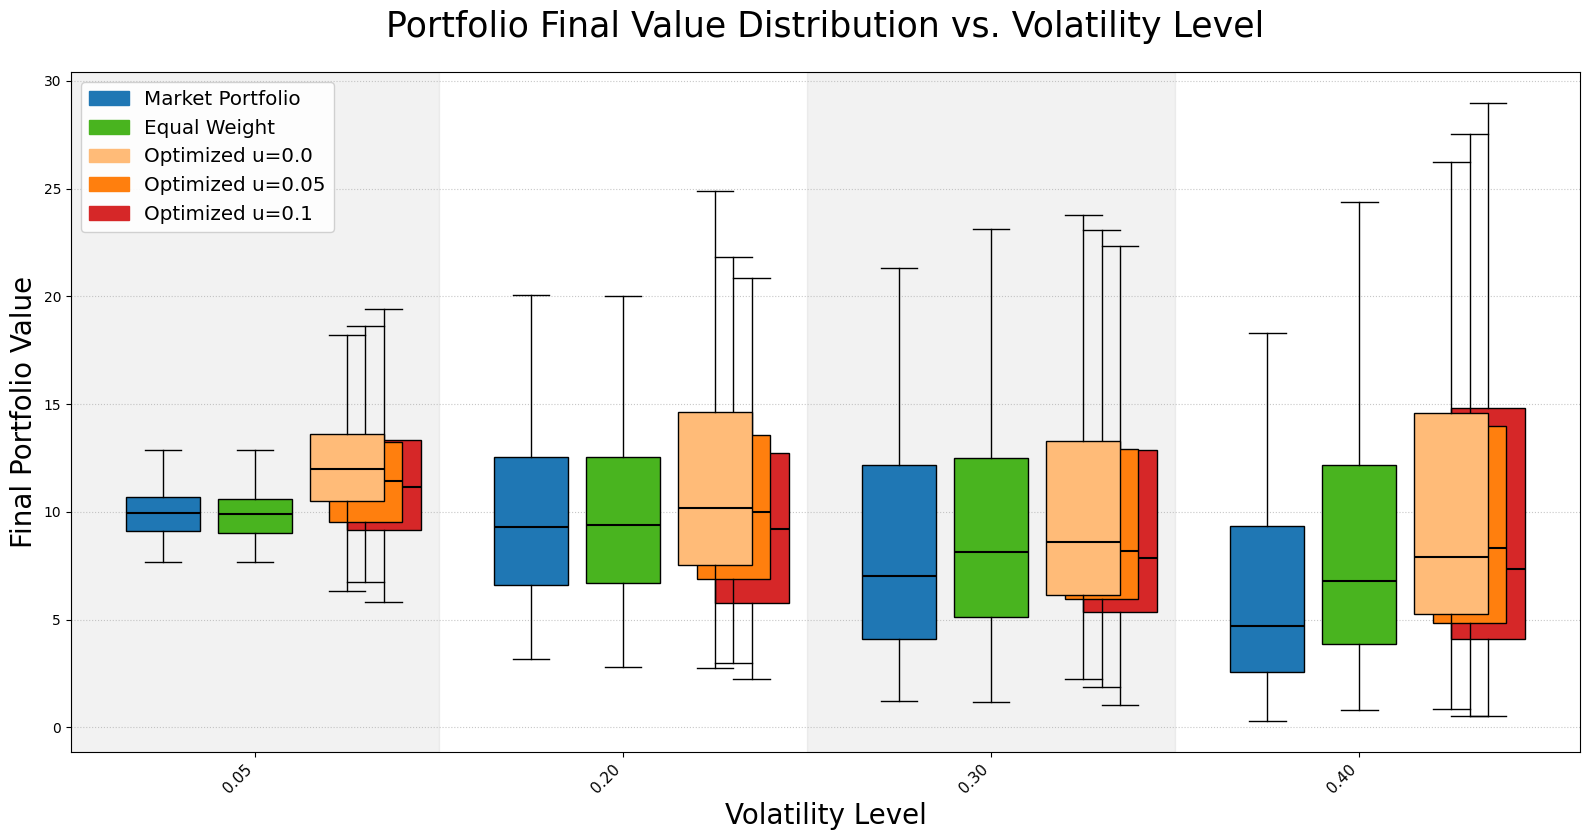

In [ ]:
group_spacing = 4
box_offset = 0.2  # horizontal spacing between the optimized boxes within a group

n_unc = len(estimation_uncertainty)

d_market, p_market = [], []
d_equal, p_equal = [], []
d_opt = [[] for _ in range(n_unc)]
p_opt = [[] for _ in range(n_unc)]
group_centers = []

for i in range(len(vola_list)):
    base = i * group_spacing

    d_market.append(mf_list[i])
    p_market.append(base)

    current_pos = base
    if include_equal_weight:
        d_equal.append(eq_list[i])
        p_equal.append(base + 1)
        current_pos = base + 1

    opt_center = current_pos + 1.2
    for k, u in enumerate(estimation_uncertainty):
        d_opt[k].append(opt_lists[u][i])
        p_opt[k].append(opt_center + (k - (n_unc - 1) / 2) * box_offset)

    group_centers.append(base + 1 if include_equal_weight else base + 0.6)


fig, ax = plt.subplots(figsize=(16, 8.5))
ax.set_title("Portfolio Final Value Distribution vs. Volatility Level", fontsize=25, pad=25)


def plot_group(data, pos, color, zorder):
    """
    Draws one set of boxes at the given positions.

    Args:
        data (list): One list of final values per volatility level.
        pos (list): X position of each box.
        color (str): Fill color of the boxes.
        zorder (int): Drawing order; higher values are drawn in front.
    """
    if not data:
        return

    bp = ax.boxplot(
        data,
        positions=pos,
        widths=0.8,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
        zorder=zorder,
    )
    for box in bp["boxes"]:
        box.set_facecolor(color)
        box.set_edgecolor("black")
        box.set_linewidth(1)
    for median in bp["medians"]:
        median.set(color="black", linewidth=1.5)


col_market = "#1f77b4"
col_equal = "#49b41f"
col_opt = ["#ffbb78", "#ff7f0e", "#d62728"]

plot_group(d_market, p_market, col_market, zorder=2)
if include_equal_weight:
    plot_group(d_equal, p_equal, col_equal, zorder=2)

# Drawn back to front, so the leftmost (lowest uncertainty) box ends up on top
for k in reversed(range(n_unc)):
    plot_group(d_opt[k], p_opt[k], col_opt[k % len(col_opt)], zorder=3 + n_unc - k)

for i, center in enumerate(group_centers):
    if i % 2 == 0:
        ax.axvspan(
            center - group_spacing / 2,
            center + group_spacing / 2,
            alpha=0.1,
            color="gray",
            zorder=0,
        )

ax.set_xticks(group_centers)
ax.set_xticklabels([f"{v:.2f}" for v in vola_list], rotation=45, ha="right", fontsize=11)
ax.set_xlabel("Volatility Level", fontsize=20)
ax.set_ylabel("Final Portfolio Value", fontsize=20)
ax.grid(axis="y", linestyle=":", alpha=0.7, zorder=0)

handles = [mpatches.Patch(color=col_market, label="Market Portfolio")]
if include_equal_weight:
    handles.append(mpatches.Patch(color=col_equal, label="Equal Weight"))
handles += [
    mpatches.Patch(color=col_opt[k % len(col_opt)], label=f"Optimized u={u}")
    for k, u in enumerate(estimation_uncertainty)
]

ax.legend(
    handles=handles,
    loc="upper left",
    prop={"size": 14.3},
    bbox_to_anchor=(0, 1),
    framealpha=0.9,
).set_zorder(100)

all_positions = p_market + (p_equal if include_equal_weight else []) + p_opt[-1]
plt.xlim(min(all_positions) - 1, max(all_positions) + 1)

plt.tight_layout()
plt.savefig("boxplot_uncertainty.pdf")
plt.show()

## Decomposition of the Master Equation

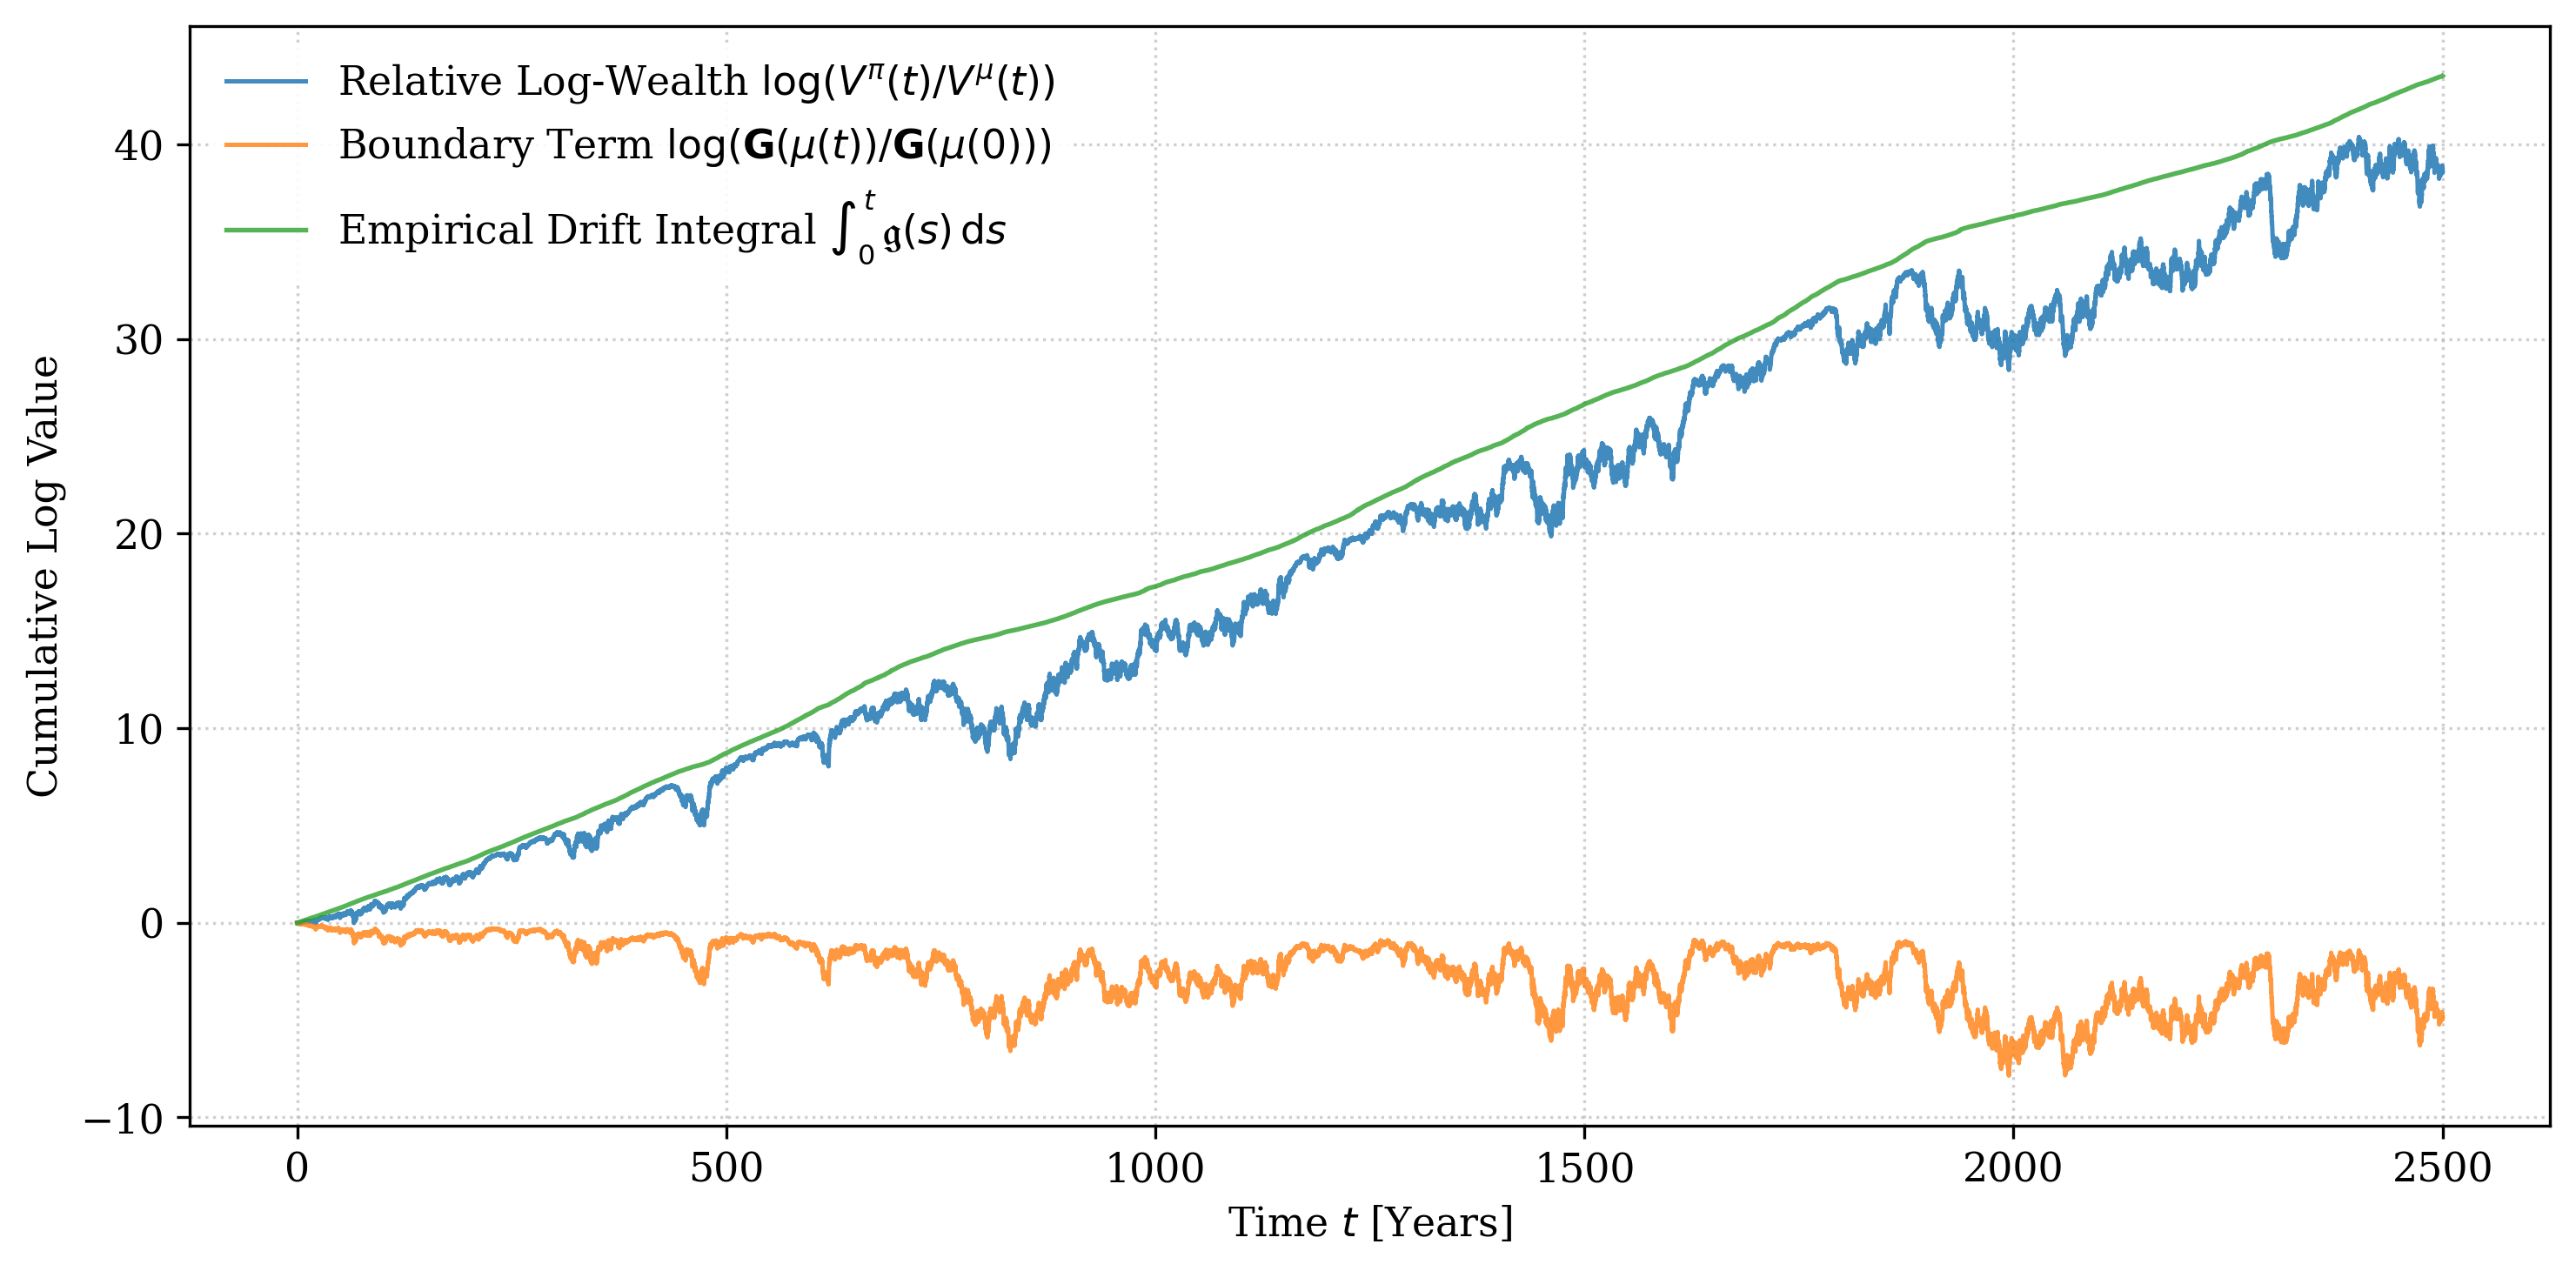

In [ ]:
# Figure 3.1 in the thesis: N_S_ME = 100, N_BM_ME = 200, T_ME = 2000, DT_ME = 0.01.
# Reduced here so that the notebook runs quickly in Colab.

N_S_ME = 24
N_BM_ME = 50
T_ME = 2500
DT_ME = 0.05

drift = np.log(1.08) * np.ones(N_S_ME)
market = Market(n_stocks=N_S_ME, n_bm=N_BM_ME, stock_volatilities=0.3, drift=drift)

entropy_rule = fgp_from_generating_function(gen_entropy)
p_gen = Portfolio(market, update_rule=entropy_rule, name="Entropy Portfolio")

stock_prices, _ = simulate_paths(market, T_ME, DT_ME, [p_gen])
time_steps = np.linspace(0, T_ME, int(T_ME / DT_ME) + 1)


# Decomposition of the master equation into boundary term and drift integral
mu_t = stock_prices / np.sum(stock_prices, axis=0)

# Relative log-wealth log(V_pi / V_mu), tracked during the simulation
log_V_rel = np.array(p_gen.log_relative_wealth)

# Boundary term log(G(mu(t)) / G(mu(0))) for G = Shannon entropy
mu_safe = np.clip(mu_t, 1e-12, 1.0)
G_t = -np.sum(mu_safe * np.log(mu_safe), axis=0)
log_G_rel = np.log(G_t / G_t[0])

# The drift integral is the remainder of the master equation
drift_integral_empirical = log_V_rel - log_G_rel


with plt.rc_context(
    {
        "font.family": "serif",
        "font.size": 11,
        "text.usetex": False,
    }
):

    fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

    ax.plot(
        time_steps,
        log_V_rel,
        label=r"Relative Log-Wealth $\log(V^\pi(t) / V^\mu(t))$",
        color="#1f77b4",
        linewidth=1.2,
        alpha=0.85,
    )
    ax.plot(
        time_steps,
        log_G_rel,
        label=r"Boundary Term $\log(\mathbf{G}(\mu(t)) / \mathbf{G}(\mu(0)))$",
        color="#ff7f0e",
        linewidth=1.2,
        alpha=0.8,
    )
    ax.plot(
        time_steps,
        drift_integral_empirical,
        label=r"Empirical Drift Integral $\int_0^t \,\mathfrak{g}(s)\,\mathrm{d}s$",
        color="#2ca02c",
        linewidth=1.3,
        alpha=0.8,
    )

    ax.set_xlabel("Time $t$ [Years]")
    ax.set_ylabel(r"Cumulative Log Value")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper left", framealpha=0.9, edgecolor="none")

    plt.tight_layout()
    plt.savefig("master_equation_decomposition.pdf")
    plt.show()

## Relative Arbitrage


In [ ]:
def sample_volatility_with_spectrum(
    n_stocks, min_eigenvalue, max_eigenvalue, seed=None
) -> np.ndarray:
    """
    Builds a volatility matrix V whose covariance C = V @ V.T has an exactly
    prescribed spectrum.

    Constructed via spectral decomposition in reverse:

        V = U @ diag(sqrt(lambda))   =>   C = U @ diag(lambda) @ U.T

    with a random orthogonal U.

    Args:
        n_stocks (int): Number of stocks n. Also the number of Brownian motions,
                        since rank(C) <= n.
        min_eigenvalue (float): Smallest eigenvalue of C.
        max_eigenvalue (float): Largest eigenvalue of C.
        seed: Seed for the random rotation U.

    Returns:
        np.ndarray: Volatility matrix V of shape (n_stocks, n_stocks).
    """

    rng = np.random.default_rng(seed)

    eigenvalues = np.linspace(min_eigenvalue, max_eigenvalue, n_stocks)
    U = ortho_group.rvs(dim=n_stocks, random_state=rng)

    return U * np.sqrt(eigenvalues)


def estimate_arbitrage_horizon(
    market,
    T: float,
    n_steps: int = 200,
    max_dt: float = 0.5,
    nsim: int = 500,
    quantile: float = 0.95,
    seed=None,
) -> dict:
    """
    Estimates the time horizon that guarantees relative arbitrage, via Monte Carlo.

    Simulates stock price paths, evaluates the time-averaged market diversity
    (1 - mu_max)^2 along each path, and combines a conservative estimate of it with the
    smallest eigenvalue of the covariance matrix to obtain the horizon

        T* = 2 n log(2) / (ε * δ_sq),

    as derived in the thesis.

    Args:
        market (Market): Market environment.
        T (float): Total simulation time horizon.
        n_steps (int, optional): Target number of time steps. Increased automatically if
            the resulting dt would exceed max_dt. Defaults to 200.
        max_dt (float, optional): Maximum allowed step size dt. Defaults to 0.5.
        nsim (int, optional): Number of Monte Carlo paths. Defaults to 500.
        quantile (float, optional): Confidence level for the diversity bound. δ_sq is
            taken as the (1 - quantile) quantile across paths, so a value of 0.95 uses the
            5% quantile and a higher value gives a more conservative bound. Defaults to 0.95.
        seed: Seed for the Monte Carlo draws.

    Returns:
        dict: With keys "epsilon" (smallest eigenvalue of the covariance matrix),
            "delta_sq" (conservative time-averaged diversity), "arbitrage_time" (T*),
            "n_steps" and "dt" (the step count and size actually used, which may differ
            from the requested n_steps).
    """

    # Ensure dt <= max_dt while keeping n_steps * dt == T
    n_steps = max(n_steps, int(np.ceil(T / max_dt)))
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)

    rng = np.random.default_rng(seed)

    # Smallest eigenvalue of covariance matrix
    epsilon = np.linalg.eigvalsh(market.covariance_matrix)[0]

    # Growth rates: g = b - 0.5 * σ_ii
    growth_rates = (market.drift_coefficients - 0.5 * np.diag(market.covariance_matrix))[
        :, np.newaxis
    ]

    log_prices = np.log(market.x0)[:, np.newaxis] * np.ones((1, nsim))

    def max_weight(log_p):
        shifted = np.exp(log_p - log_p.max(axis=0))
        return (shifted / shifted.sum(axis=0)).max(axis=0)

    # Trapezoidal rule: endpoints enter with weight 1/2
    integral_acc = 0.5 * (1.0 - max_weight(log_prices)) ** 2

    for t in range(n_steps):
        dW = rng.normal(0.0, sqrt_dt, size=(market.volatility_matrix.shape[1], nsim))
        log_prices += growth_rates * dt + market.volatility_matrix @ dW
        integral_acc += (1.0 - max_weight(log_prices)) ** 2

    # Trapezoidal rule: the final endpoint enters with weight 1/2
    integral_acc -= 0.5 * (1.0 - max_weight(log_prices)) ** 2

    # Diversity time average: (1/T) * \int_0^T (1 - max_weight)^2 dt
    integral_rates = integral_acc * dt / T

    # Conservative lower bound for delta squared
    delta_sq = np.quantile(integral_rates, 1.0 - quantile)

    # Theoretical relative arbitrage horizon
    arbitrage_time = (2 * market.n_stocks * np.log(2)) / (epsilon * delta_sq)

    return {
        "epsilon": epsilon,
        "delta_sq": delta_sq,
        "arbitrage_time": arbitrage_time,
        "n_steps": n_steps,
        "dt": dt,
    }

In [ ]:
# Figure 3.2 in the thesis: eps in [0.005, 0.5] (30 points), T in [15, 20000] (150 points),
# nsim = 2500, n_steps = 600. Reduced here so that the notebook runs quickly in Colab.

n_stocks = 5  # Number of stocks in the market
g_target = np.log(1.04)  # Target growth rate, identical for all stocks
n_steps = 500  # Lower bound for the number of steps per simulation (dt = T / n_steps)
nsim = 550  # Monte Carlo paths per grid point

# Epsilon: non-degeneracy parameter, i.e. the smallest eigenvalue of the covariance matrix
eps_start = 0.005
eps_end = 2.0
eps_num = 20
condition_number = 1.5  # Condition number of the covariance matrix (lambda_max / lambda_min)

# Time horizon T
T_start = 15
T_end = 2500
T_num = 35

# Quadratic spacing to increase sampling density near the lower parameter bounds
epsilon_vals = eps_start + (eps_end - eps_start) * (np.linspace(0, 1, eps_num) ** 2)
T_vals = T_start + (T_end - T_start) * (np.linspace(0, 1, T_num) ** 2)

E, T_mesh = np.meshgrid(epsilon_vals, T_vals)
Z_time = np.zeros_like(E)
Z_delta = np.zeros_like(E)


# One volatility matrix per epsilon, reused across all T grid points
markets_by_epsilon = {}

for eps in epsilon_vals:
    max_variance = eps * condition_number
    volatility_matrix = sample_volatility_with_spectrum(
        n_stocks=n_stocks, min_eigenvalue=eps, max_eigenvalue=max_variance
    )
    variances = np.diag(volatility_matrix @ volatility_matrix.T)

    # Drift b_i = γ + 0.5 * σ_ii, so that all stocks share the growth rate γ
    drift = g_target + 0.5 * variances

    markets_by_epsilon[eps] = Market(
        n_stocks=n_stocks,
        n_bm=volatility_matrix.shape[1],
        drift=drift,
        stock_volatilities=volatility_matrix,
    )


def compute_grid_point(i, j, eps, t_val):
    """
    Evaluates the arbitrage horizon and the diversity bound for one grid point.

    Args:
        i (int): Row index in the parameter grid.
        j (int): Column index in the parameter grid.
        eps (float): Non-degeneracy parameter of the market.
        t_val (float): Simulation horizon T.

    Returns:
        tuple: (i, j, arbitrage_time, delta_sq).
    """
    market = markets_by_epsilon[eps]
    result = estimate_arbitrage_horizon(
        market, T=t_val, n_steps=n_steps, nsim=nsim, quantile=0.95, max_dt=1.0
    )
    return i, j, result["arbitrage_time"], result["delta_sq"]


print(f"Running parallel Monte Carlo on {multiprocessing.cpu_count()} CPU cores...")

tasks = [(i, j, E[i, j], T_mesh[i, j]) for i in range(E.shape[0]) for j in range(E.shape[1])]

parallel_generator = Parallel(n_jobs=-1, return_as="generator")(
    delayed(compute_grid_point)(i, j, eps, t_val) for i, j, eps, t_val in tasks
)

for i, j, arb_time, delta_sq in tqdm(
    parallel_generator, total=len(tasks), desc="Running Monte Carlo simulations"
):
    Z_time[i, j] = arb_time
    Z_delta[i, j] = delta_sq

print("Computation complete.")

Running parallel Monte Carlo on 2 CPU cores...


Running Monte Carlo simulations:   0%|          | 0/700 [00:00<?, ?it/s]

Computation complete.


In [ ]:
def log_ticks(values):
    """
    Returns 1-2-5 tick values covering the range of the given values.

    Args:
        values (np.ndarray): Data to be shown on a logarithmic axis.

    Returns:
        tuple: (tick positions in data units, tick labels). For a 3D scene axis with
            type="log", pass the positions directly; for a colorbar over log10-scaled
            surfacecolor, pass np.log10 of the positions.
    """
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    exponents = range(int(np.floor(np.log10(vmin))), int(np.ceil(np.log10(vmax))) + 1)
    ticks = [m * 10.0**e for e in exponents for m in (1, 2, 5) if vmin <= m * 10.0**e <= vmax]
    return ticks, [f"{t:g}" for t in ticks]


delta_ticks, delta_text = log_ticks(Z_delta)
time_ticks, time_text = log_ticks(Z_time)

print(
    f"n: {n_stocks}, condition_number: {condition_number}, "
    f"n_steps: {n_steps}, nsim: {nsim}, growth_target: {g_target}"
)

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "surface"}, {"type": "surface"}]],
    subplot_titles=("Market Diversity (δ²)", "Arbitrage Horizon T*"),
)

fig.add_trace(
    go.Surface(
        z=Z_delta,
        x=E,
        y=T_mesh,
        colorscale="Plasma",
        colorbar=dict(
            x=0.45,
            title="δ²",
            len=0.75,
            tickmode="array",
            tickvals=np.log10(delta_ticks),
            ticktext=delta_text,
        ),
        name="Delta",
        surfacecolor=np.log10(Z_delta),
        hovertemplate=(
            "<b>Market Diversity Surface</b><br>"
            "Epsilon (ε): %{x:.4f}<br>"
            "Time Horizon T: %{y:.1f} Yrs<br>"
            "Delta (δ²): %{z:.4f}<extra></extra>"
        ),
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Surface(
        z=Z_time,
        x=E,
        y=T_mesh,
        colorscale="Viridis",
        colorbar=dict(
            x=0.96,
            title="Time (Years)",
            len=0.75,
            tickmode="array",
            tickvals=np.log10(time_ticks),
            ticktext=time_text,
        ),
        name="Arbitrage Time",
        surfacecolor=np.log10(Z_time),
        hovertemplate=(
            "<b>Arbitrage Time Surface</b><br>"
            "Epsilon (ε): %{x:.4f}<br>"
            "Time Horizon T: %{y:.1f} Yrs<br>"
            "Arbitrage Time: %{z:.2f} Yrs<extra></extra>"
        ),
    ),
    row=1,
    col=2,
)

# Reference plane where the arbitrage horizon equals the simulation horizon; below it the
# bound is valid, above it T* would exceed the interval it was measured on
fig.add_trace(
    go.Surface(
        z=T_mesh,
        x=E,
        y=T_mesh,
        colorscale="Reds",
        opacity=0.4,
        showscale=False,
        hoverinfo="skip",
        surfacecolor=np.log10(T_mesh),
    ),
    row=1,
    col=2,
)

fig.update_layout(
    title_text="Market Diversity and the Arbitrage Horizon",
    title_x=0.5,
    width=1200,
    height=650,
    margin=dict(l=10, r=80, b=0, t=60),
)

fig.update_scenes(
    xaxis_title="Epsilon (ε)",
    yaxis_title="Time Horizon T",
    zaxis_title="Delta (δ²)",
    zaxis=dict(
        type="log",
        tickmode="array",
        tickvals=delta_ticks,
        ticktext=delta_text,
    ),
    row=1,
    col=1,
)

fig.update_scenes(
    xaxis_title="Epsilon (ε)",
    yaxis_title="Time Horizon T",
    zaxis_title="Years",
    zaxis=dict(
        type="log",
        tickmode="array",
        tickvals=time_ticks,
        ticktext=time_text,
    ),
    row=1,
    col=2,
)

config = {"toImageButtonOptions": {"scale": 3, "format": "pdf"}}
fig.show(config=config)

n: 5, condition_number: 1.5, n_steps: 500, nsim: 550, growth_target: 0.03922071315328133
